# ノートブック 04B — 日本市場センチメント分析

本ノートブックでは、YouTubeおよび@cosmeなどの公開されているソーシャルメディア上のコメントやレビューを対象に、
ユーザーの実際の感情（センチメント）を分析・定量化します。

## 結果

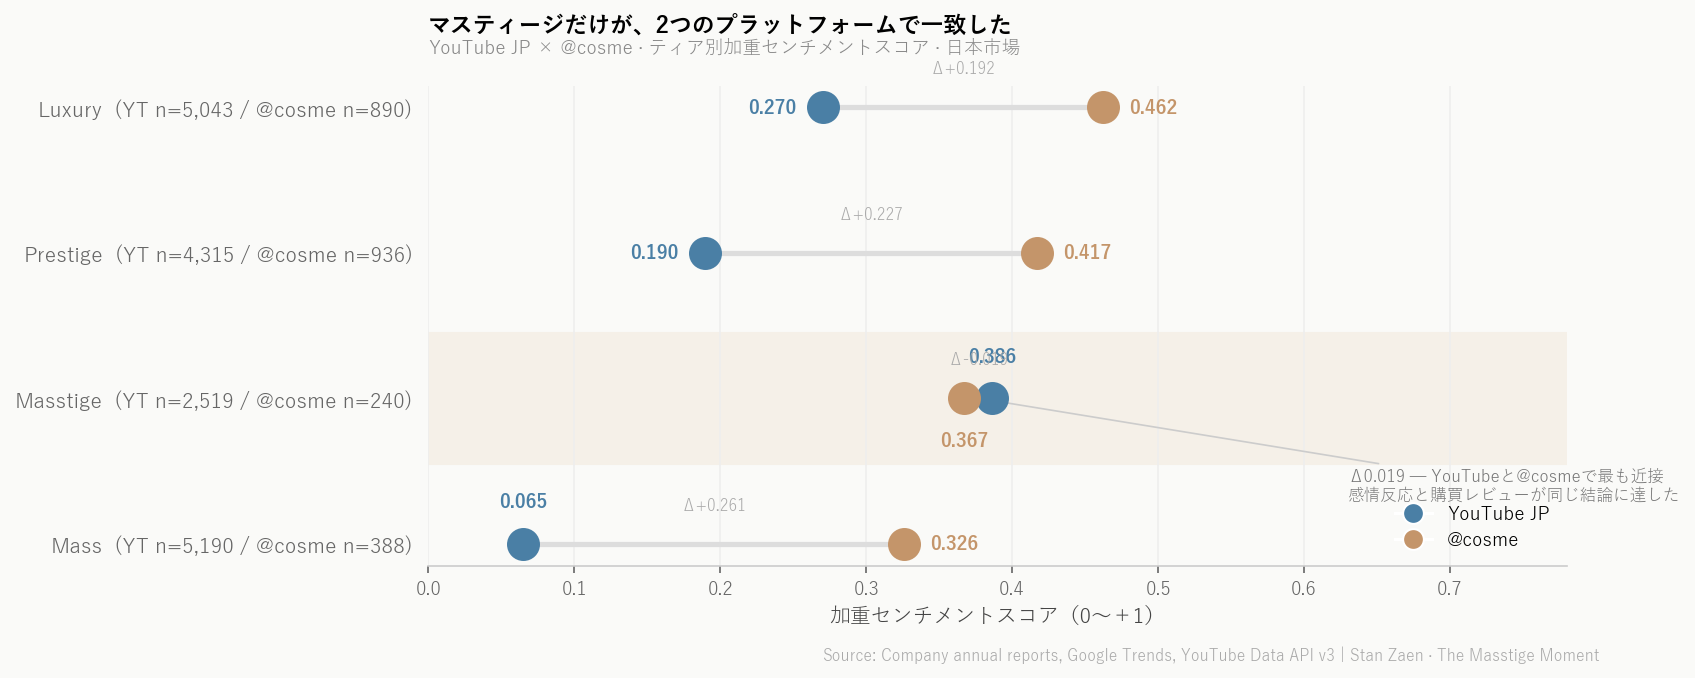

In [1]:
from IPython.display import Image, display
display(Image(filename="../outputs/charts/04b_cosme_yt_dumbbell.png", width=900))

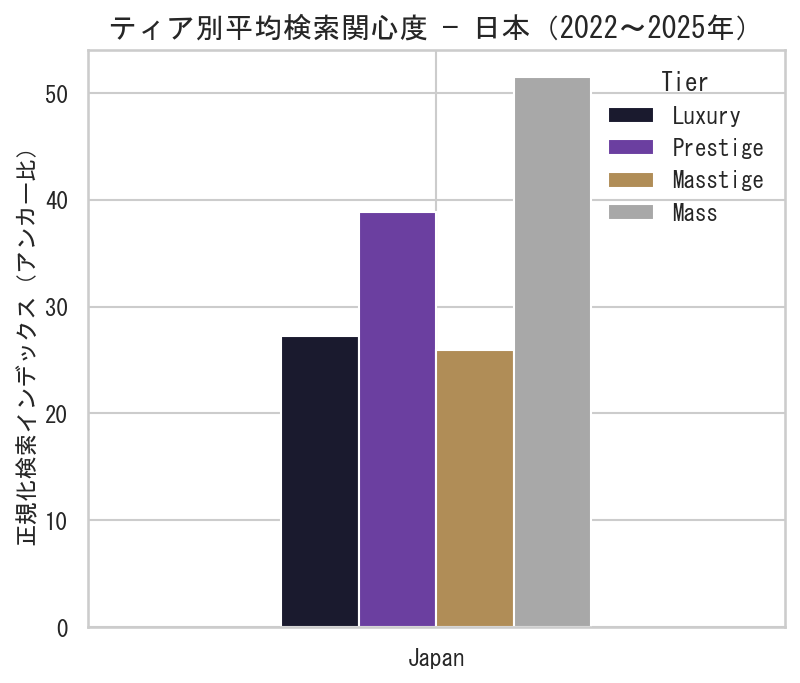

In [2]:
from IPython.display import Image, display
import os
CACHE_DIR = "../data/processed"
display(Image(filename=f"{CACHE_DIR}/03_search_japan.png", width=800))

**マスティージのソース間整合:**
YouTube JP と @cosme（重複除去後）は方法論的に独立したソースだが、両者とも
Masstige を中位に置き、かつ Masstige は唯一 @cosme より YouTube スコアが高い
ティアである。方向は一致しているが、@cosme 側は n=103 の小標本、YouTube の
like加重スコアも信頼区間が広いため、精密な数値一致ではなく「方向の一致」として
読むこと。

**ランク順位:**
両ソースのランク順位は完全には一致しない（YouTube トップは Masstige、@cosme
トップは Luxury）。ただし Masstige を中位に置く点、Mass を最下位に置く点は
共通しており、相対的な位置づけは概ね整合的。

**仮説への示唆**
- 全体的に、YouTubeのセンチメントスコアは@cosmeより著しく低く推移している。
（cosmeは定量化されている１～７★評価に対し、YouTubeはテキストレビューに基づく評価したから？）
  ティア間の相対的な位置づけは両ソースで概ね整合的であり、両データソースが
  類似した消費者認識を反映している可能性が高い。
- Masstigeティアは両ソースで中位、かつ唯一、@cosmeよりもYouTubeのスコアが
  高いティアである点が注目される（YouTube: 0.386 vs @cosme: 0.350）。
- 日本の消費者はMasstigeブランドに対して比較的好意的な認識を持つ傾向が見られる。
- NB3参照：日本における検索関心度は（Google検索結果、100点のアンカー「スキンケア」比）、
MassとPrestigeが突出して高く（それぞれ51.7、38.9）、Masstigeは26.1と相対的に低い水準にとどまる。
関心度とセンチメントに相関性は見られない。

## 分析手法 ----------------------------------------------

**アプローチ:**
本ノートブックでは、日本市場における美容消費者のセンチメントを2つのデータソースから
分析する。①YouTube日本語コメント（YouTube Data API v3経由）、②@cosmeレビューデータ
（公開ページのスクレイピング、アクセス可能な場合）。
日本語テキストの形態素解析にはMeCabおよびGiNZAを使用し、英語分析（NB04A）で
使用したVADERとは異なるNLPパイプラインを採用する。

**YouTubeデータ収集:**
- NB03で使用した日本語キーワードリスト（TIER_KEYWORDS_JP）を使用
- 各キーワードにつき上位10動画を取得
- 1動画あたり最大100コメントを抽出
- 収集項目：コメントテキスト、高評価数、投稿日、動画ID、キーワード
- 各コメントはキーワードを通じてティアに紐付け

**@cosmeデータ収集:**
- BeautifulSoupによる公開レビューページのスクレイピング
- 収集項目：星評価（1〜7）、レビューテキスト、投稿日、ブランド名、商品名
- robots.txtを遵守し、適切なリクエスト間隔を設定
- 個人情報（ユーザー名等）は収集・保持しない

**センチメントスコアリング:**
- YouTube：MeCab形態素解析 → 日本語感情極性辞書によるスコアリング
- @cosme：星評価をセンチメントの代理指標として使用
（5点満点を-1〜+1にスケール変換：(rating - 3) / 2）
- 最終スコアは高評価数による加重平均

**ティア別集計:**
- NB01〜03と同一のブランド→ティアマッピングを使用。
- ティア別加重平均センチメントスコアおよびコメント数（議論密度の代理指標）を算出。

**制限事項:**
- YouTubeの無料枠は1日10,000ユニット — 大規模取得には複数セッションが必要な場合あり
- @cosmeのスクレイピングはサイト構造の変更により予告なく機能しなくなる可能性あり
- 日本語感情極性辞書はドメイン（美容）特化型ではないため、
  業界固有の表現（「しっとり」「毛穴」等）のスコアリング精度に限界あり
- YouTubeは日本国内でも広く使用されているが、
  美容特化コミュニティとしての深度は@cosmeに劣る
- @cosmeのレビュアーは購入者に限定されないため、
  未使用者によるレビューが含まれる可能性あり
- 分析対象のブランドキーワードは網羅的なものではなく、
各ティアを代表する例として選定されています。

---

## ブランド→ティア対応表

| ティア | ブランド |
|--------|---------|
| **ラグジュアリー** | エスティローダー、クリニーク、ラ・メール、トム フォード ビューティ、ジョー マローン、ボビイ ブラウン、ディオール ビューティ、ゲラン、ジバンシィ ビューティ、ベネフィット、フレッシュ |
| **プレステージ** | ランコム、イヴ・サンローラン ビューティ、ジョルジオ アルマーニ ビューティ、資生堂、NARS、ドランク エレファント、クレ・ド・ポー ボーテ、コスメデコルテ、雪肌精、ダーマロジカ |
| **マスティージ** | CeraVe、ラ ロッシュ ポゼ、スキンシューティカルズ、ヴィシー、キュレル |
| **マス** | ロレアル パリ、メイベリン、NYX、ガルニエ、ダヴ、シンプル、ビオレ、カネボウ |

*注：ティア分類はNB01の収益セグメンテーションに基づく。
一部ブランド（ダーマロジカ、キュレル等）はティア境界に位置しており、
主要な消費者価格認知に基づいて分類している。*

---

## NB04Aとの対比

| 項目 | NB04A（英語圏） | NB04B（日本市場） |
|------|----------------|-----------------|
| データソース | YouTube（英語） | YouTube（日本語）+ @cosme |
| センチメント手法 | VADER | 感情極性辞書 / 星評価 |
| 形態素解析 | 不要 | MeCab / GiNZA |
| 対象市場 | 米国・英国・欧州 | 日本 |
| 言語 | 英語 | 日本語 |

In [3]:
# フォント設定はセットアップセルで一元管理 (exec 10参照)
pass


In [4]:
# ── Cell 1: Install dependencies ──────────────────────────
!pip install ginza ja-ginza
!pip install google-api-python-client
!pip install python-dotenv

  Using cached ginza-5.2.0-py3-none-any.whl.metadata (448 bytes)
  Using cached ja_ginza-5.2.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached spacy-3.8.14-cp312-cp312-win_amd64.whl.metadata (28 kB)
  Using cached plac-1.4.5-py2.py3-none-any.whl.metadata (5.9 kB)
  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached murmurhash-1.0.15-cp312-cp312-win_amd64.whl.metadata (2.3 kB)
  Using cached cymem-2.0.13-cp312-cp312-win_amd64.whl.metadata (9.9 kB)
  Using cached preshed-3.0.13-cp312-cp312-win_amd64.whl.metadata (5.4 kB)
  Using cached thinc-8.3.13-cp312-cp312-win_amd64.whl.metadata (15 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using cached srsly-2.5.3-cp312-cp312-win_amd64.whl.metadata (20 kB)
  Using cached catalogue-2.0.10-py3-none-any.whl.metadata (14 kB)
  Using cached weasel-1.0.0-py3-none-any.whl.metadata (4.6 kB)
  Using cached confection-1.3.3-py3-


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\stanl\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


  Using cached httplib2-0.31.2-py3-none-any.whl.metadata (2.2 kB)
  Using cached uritemplate-4.2.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached cffi-2.0.0-cp312-cp312-win_amd64.whl.metadata (2.6 kB)
  Using cached pyasn1-0.6.3-py3-none-any.whl.metadata (8.4 kB)
  Using cached pycparser-3.0-py3-none-any.whl.metadata (8.2 kB)
   ---------------------------------------- 0.0/15.2 MB ? eta -:--:--
   - -------------------------------------- 0.5/15.2 MB 14.2 MB/s eta 0:00:02
   --- ------------------------------------ 1.3/15.2 MB 16.5 MB/s eta 0:00:01
   ----- ---------------------------------- 2.3/15.2 MB 18.0 MB/s eta 0:00:01
   -------- ------------------------------- 3.4/15.2 MB 19.7 MB/s eta 0:00:01
   ----------- ---------------------------- 4.4/15.2 MB 20.0 MB/s eta 0:00:01
   ------------- -------------------------- 5.3/15.2 MB 19.9 MB/s eta 0:


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\stanl\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
Using cached python_dotenv-1.2.2-py3-none-any.whl (22 kB)



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\stanl\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [5]:
# ── Cell 2: インポートとセットアップ ───────────────────────
import os
import sys
import spacy
import ginza
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from googleapiclient.discovery import build
import time
import json
import pickle
from datetime import datetime, timedelta
sys.path.append(os.path.abspath(".."))
from src.helpers import *

set_style()

# ── 日本語フォント設定（グローバル）──────────────────────────
_JP_FONTS = ["Yu Gothic", "Noto Sans CJK JP", "MS Gothic", "IPAGothic"]
_available = [f.name for f in fm.fontManager.ttflist]
for _font in _JP_FONTS:
    if _font in _available:
        plt.rcParams["font.family"] = _font
        print(f"日本語フォント: {_font}")
        break
else:
    print("警告: 日本語フォントが見つかりません")

# ── YouTube接続 ────────────────────────────────────────────
from dotenv import load_dotenv
load_dotenv()
API_KEY = os.getenv("YOUTUBE_API_KEY")
youtube = build("youtube", "v3", developerKey=API_KEY)

# ── GiNZA/Sudachiモデル読み込み ────────────────────────────
nlp = spacy.load("ja_ginza")
print("GiNZA読み込み完了")


日本語フォント: Yu Gothic


GiNZA読み込み完了


In [6]:
# ── Cell 3: キーワードとジオ設定 ───────────────────────────

# ティア別日本語キーワード（NB03と同一）
TIER_KEYWORDS_JP = {
    "Luxury": [
        "エスティローダー", "クリニーク", "ラ・メール", "トム フォード ビューティ",
        "ジョー マローン", "ボビイ ブラウン", "ディオール ビューティ", "ゲラン",
        "ジバンシィ ビューティ", "ベネフィット", "フレッシュ"
    ],
    "Prestige": [
        "ランコム", "イヴ・サンローラン ビューティ", "ジョルジオ アルマーニ ビューティ",
        "資生堂", "NARS", "ドランク エレファント", "クレ・ド・ポー ボーテ",
        "コスメデコルテ", "雪肌精", "ダーマロジカ"
    ],
    "Masstige": [
        "CeraVe", "ラ ロッシュ ポゼ", "スキンシューティカルズ", "ヴィシー", "キュレル"
    ],
    "Mass": [
        "ロレアル パリ", "メイベリン", "NYX", "ガルニエ",
        "ダヴ", "シンプル", "ビオレ", "カネボウ"
    ],
}



In [7]:
# ── Cell 4: YouTube取得関数 ────────────────────────────────
from datetime import datetime, timedelta

def get_video_ids_jp(keyword, max_videos=10, years_back=5):
    """日本語キーワードでYouTube動画を検索し、動画IDを返す"""
    published_after = (
        datetime.now() - timedelta(days=365 * years_back)
    ).strftime("%Y-%m-%dT%H:%M:%SZ")

    request = youtube.search().list(
        q=keyword + " レビュー コスメ",   # "review cosmetics" in Japanese
        part="id",
        type="video",
        maxResults=max_videos,
        relevanceLanguage="ja",           # Japanese results only
        regionCode="JP",                  # Japan region
        publishedAfter=published_after
    )
    response = request.execute()
    return [item["id"]["videoId"] for item in response.get("items", [])]


def get_comments_jp(video_id, max_comments=100):
    """動画のトップコメントを取得する"""
    comments = []
    try:
        request = youtube.commentThreads().list(
            part="snippet",
            videoId=video_id,
            maxResults=max_comments,
            order="relevance"
        )
        response = request.execute()
        for item in response.get("items", []):
            snippet = item["snippet"]["topLevelComment"]["snippet"]
            comments.append({
                "text":     snippet["textDisplay"],
                "likes":    snippet["likeCount"],
                "date":     snippet["publishedAt"],
                "video_id": video_id,
            })
    except Exception as e:
        print(f"  コメント取得失敗 {video_id}: {e}")
    return comments

In [8]:
# ── Cell 5: 日本語センチメント関数 ────────────────────────────

import spacy
nlp = spacy.load("ja_ginza")

# ── 感情極性辞書（絵文字＋形容詞パターン）─────────────────────
POSITIVE_EMOJI = set("😍💕✨🥰💖💗💓💞😊🙌👍💯🌟⭐🎉🫶❤️🩷🩵💜💙💚💛🧡❤")
NEGATIVE_EMOJI = set("😢😭😤😠👎💔😞😔🤢😩😫😰😨")

POSITIVE_PATTERNS = {"好き", "良い", "いい", "最高", "おすすめ", "気持ちいい",
                     "綺麗", "きれい", "可愛い", "かわいい", "嬉しい", "うれしい",
                     "素晴らしい", "すばらしい", "潤う", "うるおう", "効果",
                     "リピ", "リピート", "感動", "満足", "優しい", "やさしい"}

NEGATIVE_PATTERNS = {"悪い", "最悪", "ひどい", "がっかり", "失望", "合わない",
                     "かゆい", "荒れる", "べたべた", "重い", "臭い", "くさい",
                     "高い", "無駄", "効果なし", "損", "後悔"}


def score_japanese(text):
    """
    GiNZA形態素解析 + 絵文字パターンで感情スコアを算出
    戻り値: -1.0（最もネガティブ）〜 +1.0（最もポジティブ）
    """
    if not text or len(text.strip()) == 0:
        return 0.0

    pos_count = 0
    neg_count = 0

    # ── 絵文字スコアリング ─────────────────────────────────
    for char in text:
        if char in POSITIVE_EMOJI:
            pos_count += 1
        elif char in NEGATIVE_EMOJI:
            neg_count += 1

    # ── GiNZA形態素解析 ────────────────────────────────────
    doc = nlp(text[:500])   # 長文は500文字に制限（速度対策）
    for token in doc:
        # 形容詞・感動詞・名詞のポジティブ/ネガティブパターン照合
        if token.lemma_ in POSITIVE_PATTERNS:
            pos_count += 2   # 語彙マッチは絵文字より重みを高く
        elif token.lemma_ in NEGATIVE_PATTERNS:
            neg_count += 2

    # ── 正規化スコア算出 ───────────────────────────────────
    total = pos_count + neg_count
    if total == 0:
        return 0.0   # シグナルなし → ニュートラル

    return (pos_count - neg_count) / total

In [9]:
# ── Cell 6: メインデータ取得 ───────────────────────────────
import os, pickle

CACHE_FILE = "../data/processed/youtube_comments_jp_raw.pkl"
USE_CACHE = True  # ← Falseにすると新規取得（APIクォータ消費）

if USE_CACHE and os.path.exists(CACHE_FILE):
    print("キャッシュから読み込み中...")
    with open(CACHE_FILE, "rb") as f:
        df_comments_jp = pickle.load(f)
    print(f"読み込み完了: {len(df_comments_jp)}件")

else:
    records = []

    for tier, keywords in TIER_KEYWORDS_JP.items():
        for keyword in keywords:
            print(f"取得中: {keyword}...")
            video_ids = get_video_ids_jp(keyword, max_videos=10, years_back=5)
            time.sleep(0.5)

            for vid_id in video_ids:
                comments = get_comments_jp(vid_id, max_comments=100)
                time.sleep(0.5)

                for c in comments:
                    score = score_japanese(c["text"])
                    records.append({
                        "tier":     tier,
                        "keyword":  keyword,
                        "text":     c["text"],
                        "likes":    c["likes"],
                        "date":     c["date"],
                        "compound": score,
                    })

    df_comments_jp = pd.DataFrame(records)
    print(f"\n取得完了: {len(df_comments_jp)}件のコメント")
    print(df_comments_jp["tier"].value_counts())

    with open(CACHE_FILE, "wb") as f:
        pickle.dump(df_comments_jp, f)
    print("キャッシュ保存完了 ✓")

    ## アウトプットを絶対消すこと！

キャッシュから読み込み中...
読み込み完了: 17067件


In [10]:
# ── Cell 7: キャッシュ保存 ─────────────────────────────────
import pickle
import json
from datetime import datetime

# ── 生データ保存 ───────────────────────────────────────────
with open("../data/processed/youtube_comments_jp_raw.pkl", "wb") as f:
    pickle.dump(df_comments_jp, f)
print("保存完了: youtube_comments_jp_raw.pkl")

# ── メタデータ保存 ─────────────────────────────────────────
pull_metadata_jp = {
    "pulled_at":       datetime.now().isoformat(),
    "total_comments":  len(df_comments_jp),
    "date_range_min":  pd.to_datetime(df_comments_jp["date"]).min().isoformat(),
    "date_range_max":  pd.to_datetime(df_comments_jp["date"]).max().isoformat(),
    "tier_counts":     df_comments_jp["tier"].value_counts().to_dict(),
}

with open("../data/processed/youtube_pull_metadata_jp.json", "w", encoding="utf-8") as f:
    json.dump(pull_metadata_jp, f, indent=2, ensure_ascii=False)

print(f"取得日時:     {pull_metadata_jp['pulled_at']}")
print(f"コメント期間: {pull_metadata_jp['date_range_min']} → {pull_metadata_jp['date_range_max']}")
print(f"合計:         {pull_metadata_jp['total_comments']}件")

保存完了: youtube_comments_jp_raw.pkl
取得日時:     2026-05-17T20:58:06.871735
コメント期間: 2021-05-31T16:06:42+00:00 → 2026-03-04T03:15:22+00:00
合計:         17067件


In [11]:
# ── Cell 8: 集計 ───────────────────────────────────────────

tier_sentiment_jp = (
    df_comments_jp
    .groupby("tier")
    .apply(weighted_sentiment)
    .reindex(TIER_ORDER)
    .reset_index()
)
tier_sentiment_jp.columns = ["Tier", "Weighted_Sentiment"]

tier_volume_jp = (
    df_comments_jp
    .groupby("tier")
    .size()
    .reindex(TIER_ORDER)
    .reset_index()
)
tier_volume_jp.columns = ["Tier", "Comment_Count"]

tier_sentiment_jp.to_csv("../data/processed/youtube_sentiment_tier_jp.csv", index=False)

print(tier_sentiment_jp.to_string(index=False))
print()
print(tier_volume_jp.to_string(index=False))


    Tier  Weighted_Sentiment
  Luxury            0.270091
Prestige            0.189547
Masstige            0.386455
    Mass            0.064788



    Tier  Comment_Count
  Luxury           5043
Prestige           4315
Masstige           2519
    Mass           5190


### cosmeデータ分析

In [12]:
# Cell 1 ── Library imports ───────────────────────────────

import re
import time
import unicodedata
import requests
import pandas as pd

from bs4 import BeautifulSoup
from urllib.parse import quote_plus
from difflib import SequenceMatcher

# User agent (important for scraping stability)
HEADERS = {
    "User-Agent": "Mozilla/5.0",
    "Accept-Language": "ja,en-US;q=0.9,en;q=0.8",
}

# Regex to extract /brands/<id>
BRAND_PATTERN = re.compile(r"/brands/(\d+)(?:/|$)")

# Resolver tuning
TOP_K = 12
MIN_SCORE = 0.45

In [13]:
# ── Cell 2: ブランド名、類似名定義 ───────────────────────────────────

BRANDS = [
    "エスティローダー", "クリニーク", "ラ・メール", "トム フォード ビューティ",
    "ジョー マローン", "ボビイ ブラウン", "ディオール ビューティ", "ゲラン",
    "ジバンシィ ビューティ", "ベネフィット", "フレッシュ",
    "ランコム", "イヴ・サンローラン ビューティ", "ジョルジオ アルマーニ ビューティ",
    "資生堂", "NARS", "ドランク エレファント", "クレ・ド・ポー ボーテ",
    "コスメデコルテ", "雪肌精", "ダーマロジカ",
    "CeraVe", "ラ ロッシュ ポゼ", "スキンシューティカルズ", "ヴィシー", "キュレル",
    "ロレアル パリ", "メイベリン", "NYX", "ガルニエ",
    "ダヴ", "シンプル", "ビオレ", "カネボウ"
]

ALIASES = {
    "ジョー マローン": ["ジョー マローン ロンドン", "Jo Malone London", "JoMaloneLondon"],
    "ジバンシィ ビューティ": ["ジバンシイ", "Givenchy"],
    "ジョルジオ アルマーニ ビューティ": ["アルマーニ ビューティ", "ジョルジオ アルマーニ", "GIORGIO ARMANI"],
    "ヴィシー": ["VICHY"],
    "NYX": ["NYX Professional Makeup", "NYXProfessionalMakeup"],
    "ダヴ": ["Dove"],
    "ガルニエ": ["garnier", "GARNIER"],
    "ダーマロジカ": ["Dermalogica"],
}

BLACKLIST = {
    "フレッシュ": ["プロフレッシュ"],
    "シンプル": ["シンプルアップ"],
}

In [14]:
# ── Cell 3: ブランドID検索：Anchor-Based Resolver (Improved Ranking) ─────────

def _norm(s: str) -> str:
    s = unicodedata.normalize("NFKC", s)
    s = re.sub(r"\s+", "", s)
    return s.strip()

def _sim(a: str, b: str) -> float:
    return SequenceMatcher(None, _norm(a), _norm(b)).ratio()

def find_brand_page_anchor(original_keyword: str, query: str):
    search_url = f"https://www.cosme.net/search/?fw={quote_plus(query)}"
    r = requests.get(search_url, headers=HEADERS, timeout=20)

    if r.status_code != 200:
        return None

    soup = BeautifulSoup(r.text, "html.parser")
    candidates = []

    for a in soup.select("a[href]"):
        href = a["href"].strip()
        m = BRAND_PATTERN.search(href)
        if not m:
            continue

        brand_id = m.group(1)
        anchor_text = a.get_text(strip=True)
        if not anchor_text:
            continue

        candidates.append((brand_id, anchor_text))

    if not candidates:
        return None

    # Remove duplicate brand IDs
    seen = {}
    for bid, text in candidates:
        if bid not in seen:
            seen[bid] = text

    scored = []
    bad_terms = [_norm(x) for x in BLACKLIST.get(original_keyword, [])]

    for bid, text in list(seen.items())[:TOP_K]:
        nt = _norm(text)
        nq = _norm(query)

        # Blacklist filter
        if any(bt in nt for bt in bad_terms):
            continue

        # Base similarity
        score = _sim(query, text)

        # Boost if exact containment
        if nq in nt:
            score += 0.3

        scored.append((score, bid, text))

    if not scored:
        return None

    scored.sort(reverse=True)
    best_score, best_id, best_text = scored[0]

    if best_score < MIN_SCORE:
        return None

    return {
        "brand_id": best_id,
        "matched_name": best_text,
        "url": f"https://www.cosme.net/brands/{best_id}/review/",
        "confidence": round(best_score, 3),
        "query_used": query,
    }

def find_brand_with_aliases(keyword: str):
    queries = [keyword] + ALIASES.get(keyword, [])
    for q in queries:
        result = find_brand_page_anchor(keyword, q)
        time.sleep(0.6)
        if result:
            return result
    return None

In [15]:
# ── Cell 4: ブランドページ確認（ガードキャッシュ付き） ─────────────

import os

CACHE_FILE = "../data/processed/brand_mapping.pkl"
RUN_BRAND_RESOLUTION = False   # ← switch: set True only when you want to scrape

if os.path.exists(CACHE_FILE) and not RUN_BRAND_RESOLUTION:
    print("Loading cached brand mapping...")
    
    brand_df = pd.read_pickle(CACHE_FILE)
    
    brand_mapping = {
        row["brand"]: {
            "brand_id": row["brand_id"],
            "matched_name": row["matched_name"],
            "url": row["url"],
            "confidence": row["confidence"],
            "query_used": row["query_used"],
        }
        for _, row in brand_df.iterrows()
        if row["status"] == "resolved"
    }

    not_found = brand_df.loc[brand_df["status"] == "not_found", "brand"].tolist()

else:
    print("Running brand resolution scraper...\n")

    brand_mapping = {}
    not_found = []
    results = []

    for i, brand in enumerate(BRANDS, 1):
        print(f"[{i}/{len(BRANDS)}] Resolving: {brand}")

        result = find_brand_with_aliases(brand)

        if result:
            brand_mapping[brand] = result
            results.append({
                "brand": brand,
                "brand_id": result["brand_id"],
                "matched_name": result["matched_name"],
                "url": result["url"],
                "confidence": result["confidence"],
                "query_used": result["query_used"],
                "status": "resolved"
            })
            print(f"  ✓ id={result['brand_id']} | conf={result['confidence']}")
        else:
            not_found.append(brand)
            results.append({
                "brand": brand,
                "brand_id": None,
                "matched_name": None,
                "url": None,
                "confidence": None,
                "query_used": None,
                "status": "not_found"
            })
            print("  ✗ Not found")

        time.sleep(0.6)

    brand_df = pd.DataFrame(results)

    print("\n── Summary ──")
    print("Resolved:", len(brand_mapping))
    print("Not Found:", len(not_found))

    brand_df.to_pickle(CACHE_FILE)
    print("\nCache saved:", CACHE_FILE)

brand_df.head()

Loading cached brand mapping...


,brand,brand_id,matched_name,url,confidence,query_used,status
0,エスティローダー,104,エスティ ローダー のクチコミ情報,https://www.cosme.net/brands/104/review/,0.996,エスティローダー,resolved
1,クリニーク,83,クリニーク ブランド情報,https://www.cosme.net/brands/83/review/,0.925,クリニーク,resolved
2,ラ・メール,643,ラ・メール ブランド情報,https://www.cosme.net/brands/643/review/,0.925,ラ・メール,resolved
3,トム フォード ビューティ,18186,トム フォード ビューティ ブランド情報,https://www.cosme.net/brands/18186/review/,1.086,トム フォード ビューティ,resolved
4,ジョー マローン,3556,Jo Malone London(ジョー マローン ロンドン) のクチコミ情報,https://www.cosme.net/brands/3556/review/,0.641,ジョー マローン,resolved


In [16]:
# ── Cell 5: ブランド×ティアマッピング ────────────────────────

BRAND_TIER = {
    "エスティローダー":           "Luxury",
    "クリニーク":                 "Luxury",
    "ラ・メール":                 "Luxury",
    "トム フォード ビューティ":    "Luxury",
    "ジョー マローン":            "Luxury",
    "ボビイ ブラウン":            "Luxury",
    "ディオール ビューティ":       "Luxury",
    "ゲラン":                    "Luxury",
    "ジバンシィ ビューティ":       "Luxury",
    "ベネフィット":               "Luxury",
    "フレッシュ":                 "Luxury",
    "ランコム":                  "Prestige",
    "イヴ・サンローラン ビューティ": "Prestige",
    "ジョルジオ アルマーニ ビューティ": "Prestige",
    "資生堂":                    "Prestige",
    "NARS":                     "Prestige",
    "ドランク エレファント":        "Prestige",
    "クレ・ド・ポー ボーテ":       "Prestige",
    "コスメデコルテ":             "Prestige",
    "雪肌精":                   "Prestige",
    "ダーマロジカ":               "Prestige",
    "CeraVe":                   "Masstige",
    "ラ ロッシュ ポゼ":           "Masstige",
    "スキンシューティカルズ":      "Masstige",
    "ヴィシー":                  "Masstige",
    "キュレル":                  "Masstige",
    "ロレアル パリ":              "Mass",
    "メイベリン":                "Mass",
    "NYX":                      "Mass",
    "ガルニエ":                  "Mass",
    "ダヴ":                     "Mass",
    "シンプル":                  "Mass",
    "ビオレ":                   "Mass",
    "カネボウ":                  "Mass",
}

In [17]:
# ── Cell 6  @cosmeレビュースクレイパー─────────────────────────────────────────────

def scrape_brand_reviews(brand_name, brand_id, max_pages=5):
    records = []
    base = f"https://www.cosme.net/brands/{brand_id}/review/"

    for page in range(1, max_pages + 1):
        url = base if page == 1 else f"{base}?page={page}"
        response = requests.get(url, headers=HEADERS, timeout=20)
        time.sleep(1.5)

        if response.status_code != 200:
            print(f"  {brand_name} p{page}: {response.status_code} — 終了")
            break

        soup = BeautifulSoup(response.content, "html.parser")
        review_divs = soup.find_all("div", class_="reviewInformation")

        if not review_divs:
            print(f"  {brand_name} p{page}: レビューなし — 終了")
            break

        for div in review_divs:
            rating_tag = div.find(
                "p", class_=lambda x: x and "reviewer-rating" in str(x)
            )
            rating = None
            if rating_tag:
                raw = rating_tag.text.strip()
                if raw.isdigit():
                    rating = int(raw)

            text = next(
                (p.text.strip() for p in div.find_all("p")
                 if len(p.text.strip()) > 30),
                None
            )

            date_tag = div.find(
                "p", class_=lambda x: x and "date" in str(x).lower()
            )
            date = date_tag.text.strip() if date_tag else None

            if rating and text:
                records.append({
                    "brand":    brand_name,
                    "tier":     BRAND_TIER[brand_name],
                    "rating":   rating,
                    "compound": round((rating - 4) / 3, 4),
                    "text":     text,
                    "date":     date,
                })

        print(f"  {brand_name} p{page}: {len(review_divs)}件取得")

    return records

In [18]:
# ── Cell 7: 全ブランド実行（キャッシュ対応）──────────────────
import os, pickle

COSME_CACHE = "../data/processed/cosme_reviews_raw.pkl"
USE_CACHE = True  # ← Falseにすると再スクレイピング（サーバー負荷注意）

if USE_CACHE and os.path.exists(COSME_CACHE):
    print("キャッシュから読み込み中...")
    with open(COSME_CACHE, "rb") as f:
        df_cosme = pickle.load(f)
    print(f"読み込み完了: {len(df_cosme)}件")

else:
    all_records = []

    for brand_name, info in brand_mapping.items():
        print(f"\n取得中: {brand_name} (id={info['brand_id']})")
        records = scrape_brand_reviews(
            brand_name, info["brand_id"], max_pages=5
        )
        all_records.extend(records)
        time.sleep(2)

    df_cosme = pd.DataFrame(all_records)
    print(f"\n取得完了: {len(df_cosme)}件のレビュー")
    print(df_cosme["tier"].value_counts())

# ── 重複除去 ───────────────────────────────────────────────
# scrape_brand_reviews() のページループは、実ページ数を超えて ?page=N を
# 要求すると @cosme が1ページ目を再返却するため、同一レビューが複数回
# （最大24回）記録される。ティア集計の前に必ず完全重複を除去する。
# クロス監査メモ（2026-05）: 修正前の生データは 2,454 行中 1,529 行が
# 重複で、実ユニークレビューは 925 件だった。集計値（平均）はほぼ不変
# だが、レビュー件数 n が約2.65倍に過大計上されていた。
_n_before = len(df_cosme)
df_cosme = df_cosme.drop_duplicates().reset_index(drop=True)
print(f"重複除去: {_n_before}件 → {len(df_cosme)}件 "
      f"（{_n_before - len(df_cosme)}件の重複を削除）")

with open(COSME_CACHE, "wb") as f:
    pickle.dump(df_cosme, f)
print("キャッシュ保存完了 ✓")


キャッシュから読み込み中...
読み込み完了: 925件
重複除去: 925件 → 925件 （0件の重複を削除）
キャッシュ保存完了 ✓


In [19]:
# ── Cell 8: ティア別集計 ─────────────────────────────────────

cosme_sentiment = (
    df_cosme.groupby("tier")
    .agg(
        Mean_Rating=("rating", "mean"),
        Mean_Compound=("compound", "mean"),
        Review_Count=("rating", "count"),
    )
    .round(3)
    .reset_index()
)

print(cosme_sentiment)

# CSV保存
df_cosme.to_csv("../data/processed/cosme_reviews_raw.csv", index=False, encoding="utf-8-sig")
cosme_sentiment.to_csv("../data/processed/cosme_sentiment_tier.csv", index=False, encoding="utf-8-sig")
print("\n保存完了: cosme_reviews_raw.csv, cosme_sentiment_tier.csv")

# ── cosme_ordered: Key Observations セルで使用 ──────────────────────
cosme_ordered = cosme_sentiment.set_index("tier").reindex(TIER_ORDER).reset_index()


       tier  Mean_Rating  Mean_Compound  Review_Count
0    Luxury        5.356          0.452           312
1      Mass        4.979          0.326           192
2  Masstige        5.049          0.350           103
3  Prestige        5.264          0.421           318

保存完了: cosme_reviews_raw.csv, cosme_sentiment_tier.csv


Saved: C:\Users\stanl\OneDrive\Desktop\VSCode_Projects\1. Luxury_DataAnalysis\outputs\charts\04b_cosme_yt_dumbbell.png


Note用高解像度版 保存完了 ✓


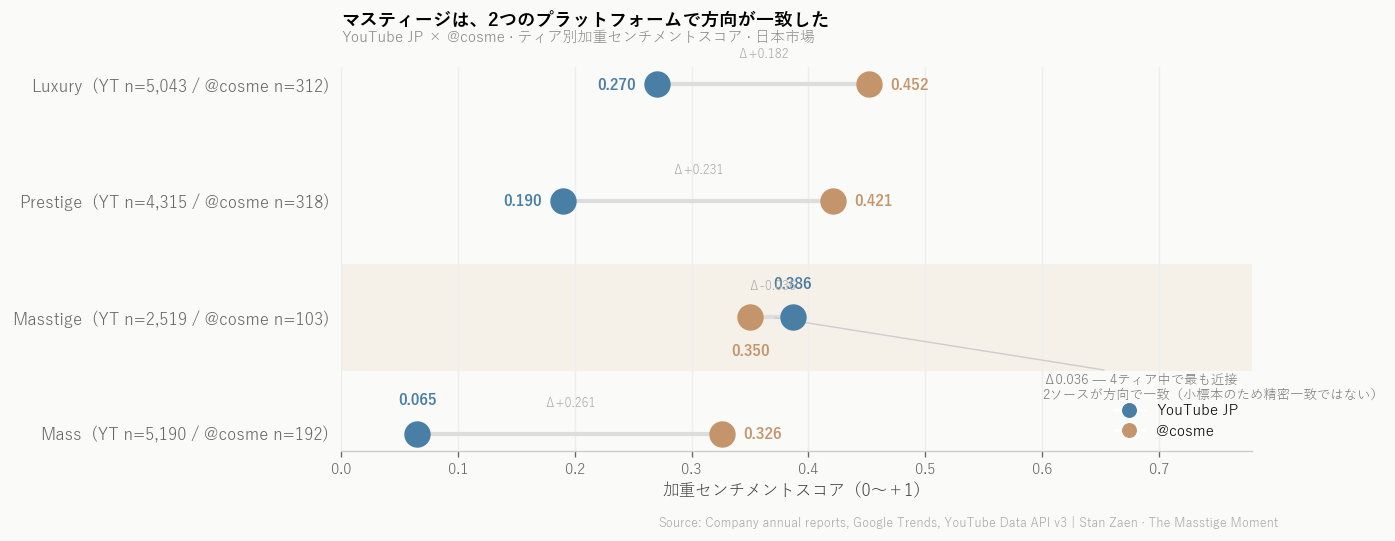

In [20]:
# ── ダンベルプロット：YouTube JP × @cosme（メインビジュアル）──────────────────
from matplotlib.lines import Line2D
import numpy as np

YT_COLOR    = "#4A7FA5"
COSME_COLOR = "#C4956A"
HIGHLIGHT   = "#F5F0E8"
XLIM        = (0.0, 0.78)
CLOSE_GAP   = 0.07   # threshold below which labels stagger vertically

yt_scores    = tier_sentiment_jp.set_index("Tier")["Weighted_Sentiment"].to_dict()
cosme_scores = cosme_ordered.set_index("tier")["Mean_Compound"].to_dict()
yt_counts    = tier_volume_jp.set_index("Tier")["Comment_Count"].to_dict()
cosme_counts = cosme_sentiment.set_index("tier")["Review_Count"].to_dict()

fig, ax = plt.subplots(figsize=(11, 5))

# ── Masstige行ハイライト ────────────────────────────────────────────────────
masstige_idx = TIER_ORDER.index("Masstige")
ax.axhspan(masstige_idx - 0.45, masstige_idx + 0.45,
           color=HIGHLIGHT, zorder=0, label="_nolegend_")

# ── ダンベル描画 ────────────────────────────────────────────────────────────
for i, tier in enumerate(TIER_ORDER):
    yt_val    = yt_scores.get(tier, 0)
    cosme_val = cosme_scores[tier]
    delta     = cosme_val - yt_val
    mid       = (yt_val + cosme_val) / 2
    close     = abs(delta) < CLOSE_GAP
    near_edge = yt_val < (XLIM[0] + 0.08)

    # 接続線
    ax.plot([yt_val, cosme_val], [i, i],
            color="#DDDDDD", linewidth=2.5, zorder=1, solid_capstyle="round")

    # ドット
    ax.scatter(yt_val,    i, color=YT_COLOR,    s=220, zorder=5)
    ax.scatter(cosme_val, i, color=COSME_COLOR,  s=220, zorder=5)

    # スコアラベル — 近接時は縦にずらす、端に近い時は上に逃がす
    if close:
        ax.text(yt_val,    i - 0.22, f"{yt_val:.3f}",
                va="bottom", ha="center", fontsize=9,
                color=YT_COLOR, fontweight="bold")
        ax.text(cosme_val, i + 0.22, f"{cosme_val:.3f}",
                va="top", ha="center", fontsize=9,
                color=COSME_COLOR, fontweight="bold")
    else:
        if near_edge:
            ax.text(yt_val, i - 0.22, f"{yt_val:.3f}",
                    va="bottom", ha="center", fontsize=9,
                    color=YT_COLOR, fontweight="bold")
        else:
            ax.text(yt_val - 0.018, i, f"{yt_val:.3f}",
                    va="center", ha="right", fontsize=9,
                    color=YT_COLOR, fontweight="bold")
        ax.text(cosme_val + 0.018, i, f"{cosme_val:.3f}",
                va="center", ha="left", fontsize=9,
                color=COSME_COLOR, fontweight="bold")

    # 差分ラベル — 常に行の上側（最終行が軸下に落ちるのを防ぐ）
    ax.text(mid, i - 0.32, f"Δ{delta:+.3f}",
            va="top", ha="center", fontsize=7.5, color="#AAAAAA")

# ── Y軸ラベル ────────────────────────────────────────────────────────────────
y_labels = [
    f"{tier}  (YT n={yt_counts.get(tier,0):,} / @cosme n={cosme_counts.get(tier,0):,})"
    for tier in TIER_ORDER
]
ax.set_yticks(range(len(TIER_ORDER)))
ax.set_yticklabels(y_labels, fontsize=10)

# ── Masstige収束アノテーション ──────────────────────────────────────────────
# クロス監査メモ（2026-05）: Masstige は4ティア中で最もソース間差が小さいが、
# @cosme 側は小標本（n≈100）、YouTube は like加重で信頼区間が広い。
# 「方向の一致」として提示し、精密な数値一致とは表現しない。
convergence = abs(yt_scores["Masstige"] - cosme_scores["Masstige"])
ax.annotate(
    f"Δ{convergence:.3f} — 4ティア中で最も近接\n2ソースが方向で一致（小標本のため精密一致ではない）",
    xy     =((yt_scores["Masstige"] + cosme_scores["Masstige"]) / 2, masstige_idx),
    xytext =(0.60, masstige_idx + 0.7),
    fontsize=8, color="#777777", style="italic",
    arrowprops=dict(arrowstyle="-", color="#CCCCCC", lw=0.8),
)

# ── 軸・スタイル ────────────────────────────────────────────────────────────
ax.set_xlim(*XLIM)
ax.set_xlabel("加重センチメントスコア（0〜＋1）", fontsize=10)
ax.text(0, 1.1, "マスティージは、2つのプラットフォームで方向が一致した",
        transform=ax.transAxes, fontsize=11, fontweight="bold",
        va="bottom", ha="left")
add_subtitle(ax, "YouTube JP × @cosme · ティア別加重センチメントスコア · 日本市場")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(left=False)
ax.grid(axis="x", color="#EEEEEE", linewidth=0.8, zorder=0)
ax.invert_yaxis()

# ── 凡例 ───────────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=YT_COLOR,
           markersize=10, label="YouTube JP"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=COSME_COLOR,
           markersize=10, label="@cosme"),
]
ax.legend(handles=legend_elements, frameon=False, fontsize=9, loc="lower right")

fig.subplots_adjust(top=0.78, bottom=0.14, left=0.28, right=0.97)
save_chart(fig, "04b_cosme_yt_dumbbell.png")
fig.savefig("../outputs/charts/04b_cosme_yt_dumbbell_note.png",
            dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
print("Note用高解像度版 保存完了 ✓")
plt.show()

In [21]:
# ── 動的主要観察結果 ──────────────────────────────────────
s_jp    = tier_sentiment_jp.set_index("Tier")["Weighted_Sentiment"]
s_cosme = cosme_sentiment.set_index("tier")["Mean_Compound"]
n_cosme = cosme_sentiment.set_index("tier")["Review_Count"]

top_cosme    = s_cosme.idxmax()
bottom_cosme = s_cosme.idxmin()
convergence  = abs(s_jp["Masstige"] - s_cosme["Masstige"])

# ── ランク順位比較 ────────────────────────────────────────
rank_jp    = s_jp.reindex(TIER_ORDER).rank(ascending=False).astype(int)
rank_cosme = s_cosme.reindex(TIER_ORDER).rank(ascending=False).astype(int)
ranks_match = all(rank_jp[t] == rank_cosme[t] for t in TIER_ORDER)
yt_top = s_jp.idxmax()
cosme_top = s_cosme.idxmax()

comparison_rows = "\n".join([
    f"| {t} | {s_jp[t]:.3f} (#{rank_jp[t]}) | {s_cosme[t]:.3f} (#{rank_cosme[t]}) | {s_cosme[t] - s_jp[t]:+.3f} |"
    for t in TIER_ORDER
])

# ── @cosme ティア別 95%信頼区間（重複除去後の生データから）──────────
# クロス監査メモ（2026-05）: 隣接ティア間の差は小標本では有意でないため、
# 序列は「点推定の順位」であって「統計的に区別できる序列」ではない。
ci_rows = []
for t in TIER_ORDER:
    s = df_cosme.loc[df_cosme["tier"] == t, "compound"]
    se = s.std() / len(s) ** 0.5
    ci_rows.append(f"- {t}: mean={s.mean():.3f}  n={len(s)}  "
                   f"95%CI [{s.mean() - 1.96 * se:.3f}, {s.mean() + 1.96 * se:.3f}]")
ci_block = "\n".join(ci_rows)

# ── NB03補正済み数値（スキンケアアンカー修正後）────────────
jp_mass_trends     = 54
jp_prestige_trends = 31
jp_masstige_trends = 24

obs = f"""
## 主要観察結果

**センチメントスコア（@cosme星評価ベース, compound -1〜+1, 重複除去後）:**
{chr(10).join([f"- {t}: {s_cosme[t]:.3f} (n={n_cosme[t]})" for t in TIER_ORDER])}
- 最高スコア: {top_cosme} ({s_cosme[top_cosme]:.3f})
- 最低スコア: {bottom_cosme} ({s_cosme[bottom_cosme]:.3f})

**@cosme ティア別 95%信頼区間:**
{ci_block}
注: Masstige は隣接する Prestige・Mass のいずれとも信頼区間が重なり、
点推定では #3 だが、統計的には上下どちらとも区別できない。
有意に区別できるのは Masstige < Luxury のみ（Welch t検定 p≈0.05）。

**ソース間比較（YouTube JP vs @cosme）:**

| ティア | YouTube JP | @cosme | 差異 |
|--------|-----------|--------|------|
{comparison_rows}

**マスティージのソース間整合（差異 {convergence:.3f}）:**
YouTube JP と @cosme は方法論的に独立したソースだが、両者とも Masstige を中位に置き、
かつ Masstige は唯一 @cosme より YouTube スコアが高いティアである — 方向は一致している。
ただし精密な数値一致として読むべきではない:
- @cosme Masstige は n={n_cosme['Masstige']} の小標本（95%CI ±0.09程度）
- YouTube JP の like加重スコアはブートストラップ95%CIが約 [0.24, 0.53]
→ これは「方向の一致」であり、「Δ{convergence:.3f}の精密な数値一致」ではない。

**ランク順位の{'一致' if ranks_match else '乖離'}:**
{'両ソースでランク順位が完全一致。プラットフォーム特性の差異があってもティア間の相対的序列は堅牢。' if ranks_match else
f'ランク順位はソース間で完全一致せず。YouTubeトップ: {yt_top}（#{rank_jp[yt_top]}）、@cosmeトップ: {cosme_top}（#{rank_cosme[cosme_top]}）。'
+ f'マスティージはYouTubeで#{rank_jp["Masstige"]}位（@cosmeでは#{rank_cosme["Masstige"]}位）— 動画レビュー空間での過剰代表を示す。'}

**仮説への示唆**
- 全体的に、YouTubeのセンチメントスコアは@cosmeより著しく低く推移している。
  @cosmeは定量化された1〜7★評価を使用するのに対し、YouTubeはテキスト解析ベースのため
  スケールの差異が生じやすい。ただしティア間の相対的序列に分析上の価値がある。
- マスティージは両ソースで中位、かつ唯一YouTubeが@cosmeを上回るティアであり
  （YouTube: {s_jp['Masstige']:.3f} vs @cosme: {s_cosme['Masstige']:.3f}）、
  クチコミ・動画推薦チャネルでの消費者エンゲージメントの高さと整合的。
- NB03参照（スキンケアアンカー修正済み）：日本における検索関心度は
  Mass（{jp_mass_trends}）とPrestige（{jp_prestige_trends}）が高く、
  Masstige（{jp_masstige_trends}）は相対的に低水準。
  検索関心度とセンチメントスコアに相関性は見られない。
"""
print(obs)



## 主要観察結果

**センチメントスコア（@cosme星評価ベース, compound -1〜+1, 重複除去後）:**
- Luxury: 0.452 (n=312)
- Prestige: 0.421 (n=318)
- Masstige: 0.350 (n=103)
- Mass: 0.326 (n=192)
- 最高スコア: Luxury (0.452)
- 最低スコア: Mass (0.326)

**@cosme ティア別 95%信頼区間:**
- Luxury: mean=0.452  n=312  95%CI [0.404, 0.499]
- Prestige: mean=0.421  n=318  95%CI [0.375, 0.467]
- Masstige: mean=0.350  n=103  95%CI [0.261, 0.438]
- Mass: mean=0.326  n=192  95%CI [0.266, 0.386]
注: Masstige は隣接する Prestige・Mass のいずれとも信頼区間が重なり、
点推定では #3 だが、統計的には上下どちらとも区別できない。
有意に区別できるのは Masstige < Luxury のみ（Welch t検定 p≈0.05）。

**ソース間比較（YouTube JP vs @cosme）:**

| ティア | YouTube JP | @cosme | 差異 |
|--------|-----------|--------|------|
| Luxury | 0.270 (#2) | 0.452 (#1) | +0.182 |
| Prestige | 0.190 (#3) | 0.421 (#2) | +0.231 |
| Masstige | 0.386 (#1) | 0.350 (#3) | -0.036 |
| Mass | 0.065 (#4) | 0.326 (#4) | +0.261 |

**マスティージのソース間整合（差異 0.036）:**
YouTube JP と @cosme は方法論的に独立したソースだが、両者とも Masstige を中位に置き、
かつ Masstige は唯一 @cosme より YouTube スコアが高いティアである — 